In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [2]:
time = ['1 days', '2 days', '4 days', '7 days', '11 days', '17 days',
              '25 days', '37 days', '53 days', '77 days', '111 days', '158 days',
              '226 days', '323 days', '1.3 years', '1.8 years', '2.6 years',
              '3.6 years', '5.2 years', '7.3 years', '10.4 years', '14.8 years',
              '21.1 years', '30.0 years']

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Fixed dataset class for simple U-Net baseline from Iain code.

## Removing the 24-time-step output so can feed into U-Net baseline.

In [4]:
import os
import re
import numpy as np
import torch
from torch.utils.data import Dataset

#  STATISTICS CALCULATOR

def compute_dataset_statistics(root_dir):
    """
    Scans the dataset directory to compute global statistics.
    """
    files = [
        os.path.join(root_dir, f)
        for f in os.listdir(root_dir)
        if re.match(r"^data_(\d{4})\.npz$", f) and ":" not in f
    ]

    if not files:
        raise FileNotFoundError(f"No valid 'data_xxxx.npz' files found in {root_dir}")

    por_list, perm_r_list, perm_z_list = [], [], []
    scalars = {k: [] for k in ['inj', 'temp', 'depth', 'swi', 'lam', 'perf0', 'perf1']}
    pressure_max = 0.0

    for file_path in files:
        with np.load(file_path) as data:
            nz = data['porosity'].shape[0]

            # Flatten and collect active domain rows for spatial properties
            por_list.append(np.clip(data['porosity'][:nz, :], 0.0, 1.0).flatten())
            perm_r_list.append(np.log10(data['perm_r'][:nz, :]).flatten())
            perm_z_list.append(np.log10(data['perm_z'][:nz, :]).flatten())

            # Track targets and experimental parameters
            pressure_max = max(pressure_max, float(np.max(data['pressure_buildup'])))
            scalars['inj'].append(data['inj_rate'])
            scalars['temp'].append(data['temperature'])
            scalars['depth'].append(data['depth'])
            scalars['swi'].append(data['Swi'])
            scalars['lam'].append(data['lam'])
            scalars['perf0'].append(data['perf_interval'][0])
            scalars['perf1'].append(data['perf_interval'][1])

    por_all = np.concatenate(por_list)
    pr_all = np.concatenate(perm_r_list)
    pz_all = np.concatenate(perm_z_list)

    return {
        'porosity_mean': np.mean(por_all),           'porosity_std': np.std(por_all),
        'log_perm_r_mean': np.mean(pr_all),         'log_perm_r_std': np.std(pr_all),
        'log_perm_z_mean': np.mean(pz_all),         'log_perm_z_std': np.std(pz_all),

        'inj_rate_mean': np.mean(scalars['inj']),     'inj_rate_std': np.std(scalars['inj']) + 1e-8,
        'temperature_mean': np.mean(scalars['temp']), 'temperature_std': np.std(scalars['temp']) + 1e-8,
        'depth_mean': np.mean(scalars['depth']),      'depth_std': np.std(scalars['depth']) + 1e-8,
        'Swi_mean': np.mean(scalars['swi']),          'Swi_std': np.std(scalars['swi']) + 1e-8,
        'lam_mean': np.mean(scalars['lam']),          'lam_std': np.std(scalars['lam']) + 1e-8,
        'perf_0_mean': np.mean(scalars['perf0']),     'perf_0_std': np.std(scalars['perf0']) + 1e-8,
        'perf_1_mean': np.mean(scalars['perf1']),     'perf_1_std': np.std(scalars['perf1']) + 1e-8,

        'pressure_max': pressure_max if pressure_max > 0 else 1.0
    }

# TORCH TRANSFORM FOR SCALING AND NORMALIZATION

class NormalizeReservoirSample(object):
    """
    A PyTorch-compliant transform classand applies scaling and grid tensor formatting.
    """
    def __init__(self, stats):
        self.stats = stats

    def __call__(self, raw_data_dict):
        porosity = raw_data_dict['porosity']
        perm_r = raw_data_dict['perm_r']
        perm_z = raw_data_dict['perm_z']

        #  SPATIAL SCALING (Log-Transform & Z-Score)
        porosity_scaled = (porosity - self.stats['porosity_mean']) / self.stats['porosity_std']
        log_perm_r_scaled = (np.log10(perm_r) - self.stats['log_perm_r_mean']) / self.stats['log_perm_r_std']
        log_perm_z_scaled = (np.log10(perm_z) - self.stats['log_perm_z_mean']) / self.stats['log_perm_z_std']

        #  SCALAR SCALING (Pre-Broadcast Normalization)
        inj_rate_scaled = (raw_data_dict['inj_rate'] - self.stats['inj_rate_mean']) / self.stats['inj_rate_std']
        temp_scaled = (raw_data_dict['temperature'] - self.stats['temperature_mean']) / self.stats['temperature_std']
        depth_scaled = (raw_data_dict['depth'] - self.stats['depth_mean']) / self.stats['depth_std']
        Swi_scaled = (raw_data_dict['Swi'] - self.stats['Swi_mean']) / self.stats['Swi_std']
        lam_scaled = (raw_data_dict['lam'] - self.stats['lam_mean']) / self.stats['lam_std']
        perf_0_scaled = (raw_data_dict['perf_interval'][0] - self.stats['perf_0_mean']) / self.stats['perf_0_std']
        perf_1_scaled = (raw_data_dict['perf_interval'][1] - self.stats['perf_1_mean']) / self.stats['perf_1_std']

        #  DATA TENSOR FORMATTING & PADDING
        input_array = np.zeros((10, 96, 200))
        nz = porosity.shape[0]

        input_array[0, :nz, :] = porosity_scaled
        input_array[1, :nz, :] = log_perm_r_scaled
        input_array[2, :nz, :] = log_perm_z_scaled

        input_array[3, :, :] = np.ones((96, 200)) * inj_rate_scaled
        input_array[4, :, :] = np.ones((96, 200)) * temp_scaled
        input_array[5, :, :] = np.ones((96, 200)) * depth_scaled
        input_array[6, :, :] = np.ones((96, 200)) * Swi_scaled
        input_array[7, :, :] = np.ones((96, 200)) * lam_scaled
        input_array[8, :, :] = np.ones((96, 200)) * perf_0_scaled
        input_array[9, :, :] = np.ones((96, 200)) * perf_1_scaled

        input_tensor = torch.from_numpy(input_array).float()

        #  TARGET SCALING
        output_array = np.zeros((2, 96, 200, 24))
        output_array[0, :nz, :, :] = raw_data_dict['pressure_buildup'] / self.stats['pressure_max']
        output_array[1, :nz, :, :] = raw_data_dict['gas_saturation']

        output_tensor = torch.from_numpy(output_array).float()

        return input_tensor, output_tensor

# RESERVOIR DATASET CLASS

class reservoir_dataset(Dataset):
    """
    Custom PyTorch Dataset for parsing and validating multi-variable
    reservoir grid simulations dynamically during model training.
    """
    def __init__(self, root_dir, transform=None):
        if not root_dir.endswith('/'):
            root_dir += '/'
        self.root_dir = root_dir
        self.transform = transform

        # FIX: Scan and store the actual filenames that exist on disk
        self.valid_files = sorted([
            f for f in os.listdir(self.root_dir)
            if re.match(r"^data_(\d{4})\.npz$", f) and ":" not in f
        ])

    def __len__(self):
        # FIX: Return the true count of discovered files
        return len(self.valid_files)

    def __getitem__(self, index):
        input_list, output_list = [], []
        if isinstance(index, int):
            index = [index]

        for idx in index:
            # FIX: Map PyTorch's sequential index to the actual filename string
            filename = self.valid_files[idx]
            file_path = os.path.join(self.root_dir, filename)

            with np.load(file_path) as data:
                porosity = data['porosity']
                gas_saturation = data['gas_saturation']
                perm_r = data['perm_r']
                perm_z = data['perm_z']

                # --- DATA INTEGRITY QC CHECK ---
                nan_count = sum(np.isnan(arr).sum() for arr in [porosity, perm_r, perm_z, data['pressure_buildup'], gas_saturation])
                inf_count = sum(np.isinf(arr).sum() for arr in [porosity, perm_r, perm_z, data['pressure_buildup'], gas_saturation])

                if nan_count > 0 or inf_count > 0:
                    print(f"[WARNING] {filename} contains NaNs ({nan_count}) or Infs ({inf_count})!")
                if np.any(perm_r <= 0.0) or np.any(perm_z <= 0.0):
                    print(f"[CRITICAL WARNING] {filename} has negative or zero permeability!")

                # In-place clipping bounds execution
                gas_saturation = np.clip(gas_saturation, 0.0, 1.0)
                porosity = np.clip(porosity, 0.0, 1.0)

                raw_sample = {
                    'porosity': porosity, 'perm_r': perm_r, 'perm_z': perm_z,
                    'pressure_buildup': data['pressure_buildup'], 'gas_saturation': gas_saturation,
                    'inj_rate': data['inj_rate'], 'temperature': data['temperature'], 'depth': data['depth'],
                    'Swi': data['Swi'], 'lam': data['lam'], 'perf_interval': data['perf_interval']
                }

                if self.transform:
                    input_tensor, output_tensor = self.transform(raw_sample)
                else:
                    input_tensor = torch.from_numpy(porosity).float()
                    output_tensor = torch.from_numpy(gas_saturation).float()

                input_list.append(input_tensor)
                output_list.append(output_tensor)

        sample = torch.stack(input_list, dim=0), torch.stack(output_list, dim=0)
        return (sample[0].squeeze(0), sample[1].squeeze(0)) if len(index) == 1 else sample

#Create dataset and test one sample

In [5]:
import os, re, random, shutil
from pathlib import Path

# =========================
# EASY SETTINGS TO CHANGE
# =========================
DATA_ROOT = "/content/drive/MyDrive/train_data_set"  # change this
N_SAMPLES = None      # use 10, 50, 100, 500, or None for full dataset
SUBSET_MODE = "first"   # "random" or "first"
SEED = 42

# =========================
# FIND ALL VALID DATA FILES
# =========================
all_files = sorted([
    Path(DATA_ROOT) / f
    for f in os.listdir(DATA_ROOT)
    if re.match(r"^data_(\d{4})\.npz$", f) and ":" not in f
])

print("Total valid files found:", len(all_files))

if N_SAMPLES is None:
    run_root = DATA_ROOT
    selected_files = all_files
else:
    if SUBSET_MODE == "random":
        random.seed(SEED)
        selected_files = all_files.copy()
        random.shuffle(selected_files)
        selected_files = selected_files[:N_SAMPLES]
    else:
        selected_files = all_files[:N_SAMPLES]

    subset_dir = Path(f"/content/reservoir_subset_{len(selected_files)}")
    if subset_dir.exists():
        shutil.rmtree(subset_dir)
    subset_dir.mkdir(parents=True, exist_ok=True)

    # Symlink files instead of copying large npz files
    for src in selected_files:
        dst = subset_dir / src.name
        try:
            os.symlink(src, dst)
        except OSError:
            shutil.copy2(src, dst)

    run_root = str(subset_dir)

print("Using folder:", run_root)
print("Number of files used:", len(selected_files))
print("Example files:", [p.name for p in selected_files[:5]])

Total valid files found: 4500
Using folder: /content/drive/MyDrive/train_data_set
Number of files used: 4500
Example files: ['data_0000.npz', 'data_0001.npz', 'data_0002.npz', 'data_0003.npz', 'data_0004.npz']


In [6]:
stats = compute_dataset_statistics(run_root)

transform = NormalizeReservoirSample(stats)
dataset = reservoir_dataset(run_root, transform=transform)

print("Dataset length:", len(dataset))

x, y = dataset[0]
print("Input x shape:", x.shape)
print("Target y shape:", y.shape)

Dataset length: 4500
Input x shape: torch.Size([10, 96, 200])
Target y shape: torch.Size([2, 96, 200, 24])


In [18]:
from torch.utils.data import DataLoader, random_split

VAL_FRACTION = 0.2
SEED = 42

n_total = len(dataset)
n_val = int(n_total * VAL_FRACTION)
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)

BATCH_SIZE = min(32, n_train)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("Total dataset:", n_total)
print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Batch size:", BATCH_SIZE)

xb, yb = next(iter(train_loader))
print("Train batch x:", xb.shape)
print("Train batch y:", yb.shape)

xb_val, yb_val = next(iter(val_loader))
print("Val batch x:", xb_val.shape)
print("Val batch y:", yb_val.shape)

Total dataset: 4500
Training samples: 3600
Validation samples: 900
Batch size: 32
Train batch x: torch.Size([32, 10, 96, 200])
Train batch y: torch.Size([32, 2, 96, 200, 24])
Val batch x: torch.Size([32, 10, 96, 200])
Val batch y: torch.Size([32, 2, 96, 200, 24])


In [25]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU(),

            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.SiLU()
        )

    def forward(self, x):
        return self.block(x)


class UNetBaseline(nn.Module):
    def __init__(self, in_channels=10, out_channels=48, base_channels=32):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)

        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)

        self.dec3 = DoubleConv(base_channels * 8 + base_channels * 4, base_channels * 4)
        self.dec2 = DoubleConv(base_channels * 4 + base_channels * 2, base_channels * 2)
        self.dec1 = DoubleConv(base_channels * 2 + base_channels, base_channels)

        self.final = nn.Conv2d(base_channels, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)              # (B, 32, 96, 200)
        e2 = self.enc2(self.pool(e1))  # (B, 64, 48, 100)
        e3 = self.enc3(self.pool(e2))  # (B, 128, 24, 50)

        b = self.bottleneck(self.pool(e3))  # (B, 256, 12, 25)

        # Decoder
        d3 = F.interpolate(b, size=e3.shape[2:], mode="bilinear", align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = F.interpolate(d3, size=e2.shape[2:], mode="bilinear", align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = F.interpolate(d2, size=e1.shape[2:], mode="bilinear", align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [26]:
def target_5d_to_4d(y):
    """
    Convert target from:
    (B, 2, H, W, 24)
    to:
    (B, 48, H, W)
    """
    B, C, H, W, T = y.shape
    return y.permute(0, 1, 4, 2, 3).contiguous().view(B, C * T, H, W)


def pred_4d_to_5d(pred):
    """
    Convert prediction from:
    (B, 48, H, W)
    back to:
    (B, 2, H, W, 24)
    """
    B, CT, H, W = pred.shape
    C = 2
    T = 24
    return pred.view(B, C, T, H, W).permute(0, 1, 3, 4, 2).contiguous()

In [27]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Rerun this cell every time to reset the model weights
model = UNetBaseline(
    in_channels=10,
    out_channels=48,
    base_channels=32
).to(device)

X_batch, y_batch = next(iter(train_loader))
X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

y_batch_4d = target_5d_to_4d(y_batch)

with torch.no_grad():
    pred = model(X_batch)

print("Input shape:      ", X_batch.shape)
print("Prediction shape: ", pred.shape)
print("Target shape 5D:  ", y_batch.shape)
print("Target shape 4D:  ", y_batch_4d.shape)

Using device: cuda
Input shape:       torch.Size([32, 10, 96, 200])
Prediction shape:  torch.Size([32, 48, 96, 200])
Target shape 5D:   torch.Size([32, 2, 96, 200, 24])
Target shape 4D:   torch.Size([32, 48, 96, 200])


In [28]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-6
)

# Maximum number of epochs
num_epochs = 100

# Early stopping settings
PATIENCE = 20       # stop if val loss does not improve for 20 epochs
MIN_DELTA = 1e-5    # minimum improvement counted as real improvement
MIN_EPOCHS = 30     # do not stop too early before this epoch

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = 0
epochs_without_improvement = 0

SAVE_PATH = "/content/drive/MyDrive/best_unet_baseline_fulldataset.pth"
CHECKPOINT_PATH = "/content/drive/MyDrive/checkpoint_unet_baseline_fulldataset.pth"

for epoch in range(num_epochs):
    # =========================
    # Training
    # =========================
    model.train()
    train_loss = 0.0

    for X, y in train_loader:
        X = X.to(device)
        y = y.to(device)

        y_target = target_5d_to_4d(y)

        optimizer.zero_grad()

        pred = model(X)
        loss = criterion(pred, y_target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * X.size(0)

    train_loss /= len(train_loader.dataset)

    # =========================
    # Validation
    # =========================
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for X, y in val_loader:
            X = X.to(device)
            y = y.to(device)

            y_target = target_5d_to_4d(y)

            pred = model(X)
            loss = criterion(pred, y_target)

            val_loss += loss.item() * X.size(0)

    val_loss /= len(val_loader.dataset)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    # =========================
    # Save best model
    # =========================
    improved = val_loss < best_val_loss - MIN_DELTA

    if improved:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        # Save best model weights only
        torch.save(model.state_dict(), SAVE_PATH)

        # Save full checkpoint too
        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "train_losses": train_losses,
            "val_losses": val_losses,
            "best_val_loss": best_val_loss,
            "best_epoch": best_epoch,
        }, CHECKPOINT_PATH)

        save_message = "saved best model"

    else:
        epochs_without_improvement += 1
        save_message = f"no improvement ({epochs_without_improvement}/{PATIENCE})"

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.6f} | "
        f"Validation Loss: {val_loss:.6f} | "
        f"{save_message}"
    )

    # =========================
    # Early stopping
    # =========================
    if (epoch + 1) >= MIN_EPOCHS and epochs_without_improvement >= PATIENCE:
        print(
            f"\nEarly stopping triggered at epoch {epoch+1}.\n"
            f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch}."
        )
        break

print(f"\nTraining finished.")
print(f"Best validation loss: {best_val_loss:.6f} at epoch {best_epoch}")
print(f"Best model saved to: {SAVE_PATH}")

Epoch [1/100] | Train Loss: 0.015085 | Validation Loss: 0.008139 | saved best model
Epoch [2/100] | Train Loss: 0.005723 | Validation Loss: 0.003713 | saved best model
Epoch [3/100] | Train Loss: 0.003188 | Validation Loss: 0.003079 | saved best model
Epoch [4/100] | Train Loss: 0.002406 | Validation Loss: 0.001899 | saved best model
Epoch [5/100] | Train Loss: 0.002041 | Validation Loss: 0.001707 | saved best model
Epoch [6/100] | Train Loss: 0.001828 | Validation Loss: 0.001453 | saved best model
Epoch [7/100] | Train Loss: 0.001640 | Validation Loss: 0.001355 | saved best model
Epoch [8/100] | Train Loss: 0.001880 | Validation Loss: 0.001491 | no improvement (1/20)
Epoch [9/100] | Train Loss: 0.001565 | Validation Loss: 0.001270 | saved best model
Epoch [10/100] | Train Loss: 0.001466 | Validation Loss: 0.001271 | no improvement (1/20)
Epoch [11/100] | Train Loss: 0.001365 | Validation Loss: 0.001111 | saved best model
Epoch [12/100] | Train Loss: 0.001307 | Validation Loss: 0.00111

In [29]:
# =========================
# Load best model after training
# =========================
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
model.eval()

UNetBaseline(
  (enc1): DoubleConv(
    (block): Sequential(
      (0): Conv2d(10, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU()
    )
  )
  (enc2): DoubleConv(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): SiLU()
    )
  )
  (enc3): DoubleConv(
    (block): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
   

# Plot the loss curve

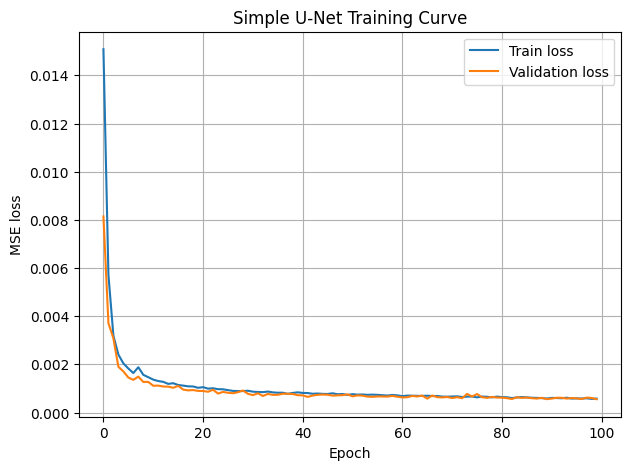

In [30]:
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Simple U-Net Training Curve")
plt.legend()
plt.grid(True)
plt.show()

# Visualize prediction quality

In [31]:
model.eval()

X_batch, y_batch = next(iter(val_loader))

X_batch = X_batch.to(device)
y_batch = y_batch.to(device)

with torch.no_grad():
    pred_4d = model(X_batch)

# Convert prediction from (B, 48, H, W) back to (B, 2, H, W, 24)
pred_5d = pred_4d_to_5d(pred_4d)

# Move to CPU
pred = pred_5d.cpu()
true = y_batch.cpu()

# Denormalise pressure only
pressure_max = stats["pressure_max"]

pred_denorm = pred.clone()
true_denorm = true.clone()

pred_denorm[:, 0, :, :, :] = pred_denorm[:, 0, :, :, :] * pressure_max
true_denorm[:, 0, :, :, :] = true_denorm[:, 0, :, :, :] * pressure_max

# Make a plotting copy only
# Do not use this clipped version for metrics
pred_denorm_plot = pred_denorm.clone()
true_denorm_plot = true_denorm.clone()

pred_denorm_plot[:, 0, :, :, :] = pred_denorm_plot[:, 0, :, :, :].clamp(min=0)
pred_denorm_plot[:, 1, :, :, :] = pred_denorm_plot[:, 1, :, :, :].clamp(0, 1)

print("X_batch shape:", X_batch.shape)
print("Raw prediction 4D shape:", pred_4d.shape)
print("Prediction 5D shape:", pred_denorm.shape)
print("True target shape:", true_denorm.shape)

X_batch shape: torch.Size([32, 10, 96, 200])
Raw prediction 4D shape: torch.Size([32, 48, 96, 200])
Prediction 5D shape: torch.Size([32, 2, 96, 200, 24])
True target shape: torch.Size([32, 2, 96, 200, 24])


In [32]:
def get_npz_path_from_subset(subset_dataset, subset_position):
    """
    Get the raw .npz file path corresponding to a sample inside val_dataset/train_dataset.

    This works when train_dataset and val_dataset were created using random_split().
    """
    original_dataset = subset_dataset.dataset
    original_index = subset_dataset.indices[subset_position]

    filename = original_dataset.valid_files[original_index]
    file_path = os.path.join(original_dataset.root_dir, filename)

    return file_path

# Plot pressure and gas saturation for one validation sample.

Raw validation file: /content/drive/MyDrive/train_data_set/data_1419.npz
Actual nz: 23


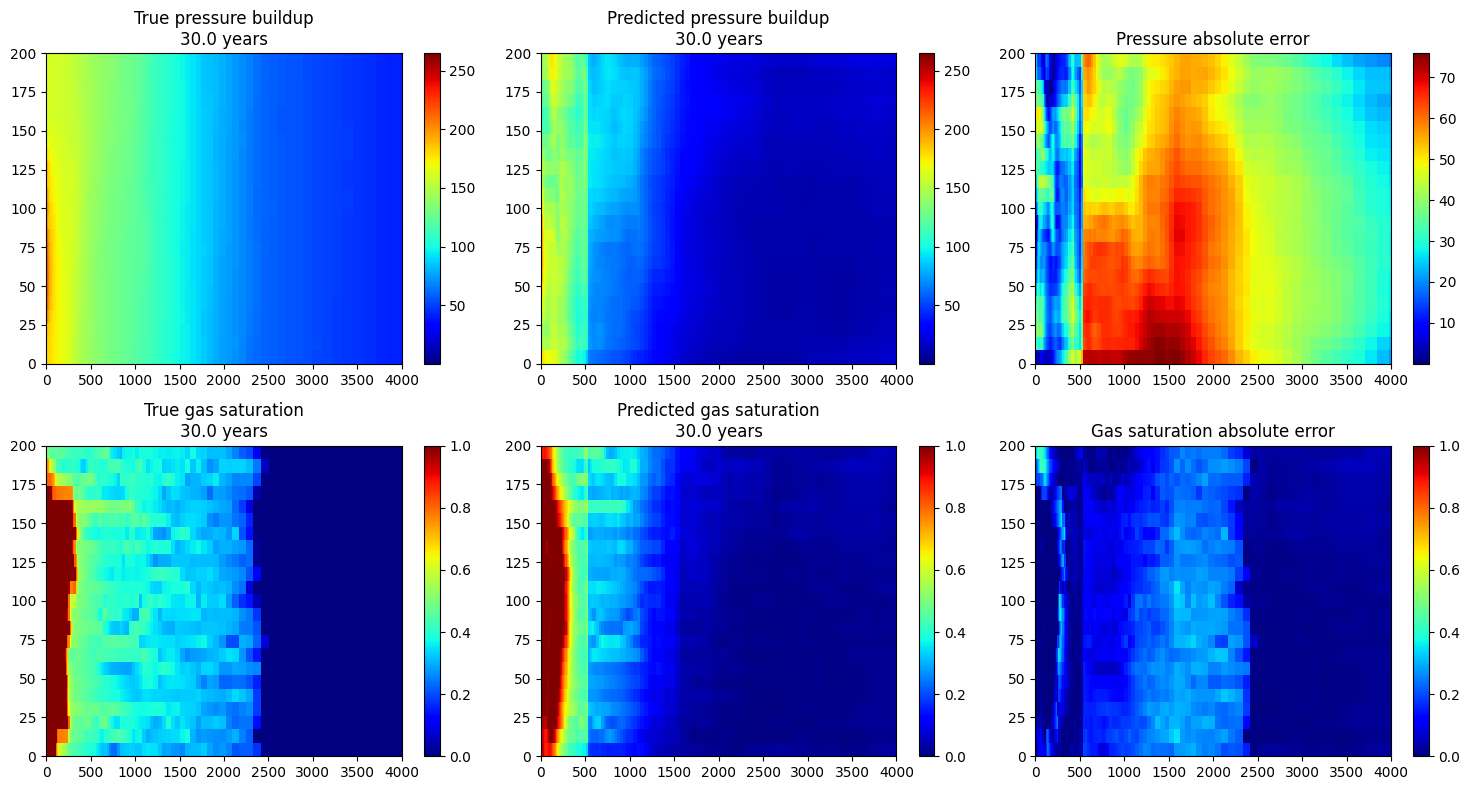

In [33]:
sample_id = 0
time_idx = 23   # 0 = 1 day, 23 = 30 years

# Get actual raw file and actual nz
raw_file = get_npz_path_from_subset(val_dataset, sample_id)

with np.load(raw_file) as data:
    nz = data["porosity"].shape[0]

print("Raw validation file:", raw_file)
print("Actual nz:", nz)

# =========================
# Extract arrays and crop to actual nz
# =========================
pressure_true = true_denorm_plot[sample_id, 0, :nz, :, time_idx].numpy()
pressure_pred = pred_denorm_plot[sample_id, 0, :nz, :, time_idx].numpy()
pressure_error = np.abs(pressure_true - pressure_pred)

gas_true = true_denorm_plot[sample_id, 1, :nz, :, time_idx].numpy()
gas_pred = pred_denorm_plot[sample_id, 1, :nz, :, time_idx].numpy()
gas_error = np.abs(gas_true - gas_pred)

# =========================
# Correct coarsening-grid edges
# =========================
dx_widths = 3.5938 * np.power(1.035012, np.arange(200))

# 201 x-edges for 200 cells
x_edges = np.concatenate(([0.1], 0.1 + np.cumsum(dx_widths)))

# nz+1 y-edges for nz vertical cells
y_edges = np.linspace(0, 200, nz + 1)

def plot_physical_grid(data, title, vmin=None, vmax=None):
    plt.pcolormesh(
        x_edges,
        y_edges,
        np.flipud(data),
        shading="flat",
        cmap="jet",
        vmin=vmin,
        vmax=vmax
    )
    plt.xlim([0, 4000])
    plt.colorbar()
    plt.title(title)

# Use true pressure scale for true/pred comparison
p_vmin = pressure_true.min()
p_vmax = pressure_true.max()

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plot_physical_grid(
    pressure_true,
    f"True pressure buildup\n{time[time_idx]}",
    vmin=p_vmin,
    vmax=p_vmax
)

plt.subplot(2, 3, 2)
plot_physical_grid(
    pressure_pred,
    f"Predicted pressure buildup\n{time[time_idx]}",
    vmin=p_vmin,
    vmax=p_vmax
)

plt.subplot(2, 3, 3)
plot_physical_grid(
    pressure_error,
    "Pressure absolute error"
)

plt.subplot(2, 3, 4)
plot_physical_grid(
    gas_true,
    f"True gas saturation\n{time[time_idx]}",
    vmin=0,
    vmax=1
)

plt.subplot(2, 3, 5)
plot_physical_grid(
    gas_pred,
    f"Predicted gas saturation\n{time[time_idx]}",
    vmin=0,
    vmax=1
)

plt.subplot(2, 3, 6)
plot_physical_grid(
    gas_error,
    "Gas saturation absolute error",
    vmin=0,
    vmax=1
)

plt.tight_layout()
plt.show()

In [34]:
import math
import pandas as pd

def get_npz_path(dataset_like, position):
    """
    Works for either:
    - val_dataset/train_dataset from random_split()
    - original reservoir_dataset
    """
    if hasattr(dataset_like, "indices"):
        original_dataset = dataset_like.dataset
        original_index = dataset_like.indices[position]
    else:
        original_dataset = dataset_like
        original_index = position

    filename = original_dataset.valid_files[original_index]
    file_path = os.path.join(original_dataset.root_dir, filename)

    return file_path


def evaluate_regression_metrics_active_only(model, subset_dataset, data_loader, device, stats):
    model.eval()

    pressure_max = stats["pressure_max"]

    metrics = {
        "pressure": {
            "n": 0,
            "sum_true": 0.0,
            "sum_true_sq": 0.0,
            "sum_abs_error": 0.0,
            "sum_sq_error": 0.0,
        },
        "gas_saturation": {
            "n": 0,
            "sum_true": 0.0,
            "sum_true_sq": 0.0,
            "sum_abs_error": 0.0,
            "sum_sq_error": 0.0,
        }
    }

    sample_counter = 0

    with torch.no_grad():
        for X, y in data_loader:
            X = X.to(device)
            y = y.to(device)

            pred_4d = model(X)
            pred_5d = pred_4d_to_5d(pred_4d)

            batch_size = X.size(0)

            for j in range(batch_size):
                raw_file = get_npz_path(subset_dataset, sample_counter)

                with np.load(raw_file) as data:
                    nz = data["porosity"].shape[0]

                # Pressure: denormalise
                pred_pressure = pred_5d[j, 0, :nz, :, :] * pressure_max
                true_pressure = y[j, 0, :nz, :, :] * pressure_max

                # Gas saturation: already physical 0-1 target
                pred_gas = pred_5d[j, 1, :nz, :, :]
                true_gas = y[j, 1, :nz, :, :]

                data_pairs = {
                    "pressure": (pred_pressure, true_pressure),
                    "gas_saturation": (pred_gas, true_gas)
                }

                for key, (pred_var, true_var) in data_pairs.items():
                    pred_flat = pred_var.reshape(-1).double()
                    true_flat = true_var.reshape(-1).double()

                    error = pred_flat - true_flat

                    metrics[key]["n"] += true_flat.numel()
                    metrics[key]["sum_true"] += true_flat.sum().item()
                    metrics[key]["sum_true_sq"] += (true_flat ** 2).sum().item()
                    metrics[key]["sum_abs_error"] += torch.abs(error).sum().item()
                    metrics[key]["sum_sq_error"] += (error ** 2).sum().item()

                sample_counter += 1

    results = []

    for key, m in metrics.items():
        n = m["n"]

        mae = m["sum_abs_error"] / n
        rmse = math.sqrt(m["sum_sq_error"] / n)

        sse = m["sum_sq_error"]
        sst = m["sum_true_sq"] - (m["sum_true"] ** 2) / n

        r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")

        results.append({
            "Variable": key,
            "MAE": mae,
            "RMSE": rmse,
            "R2": r2
        })

    return pd.DataFrame(results)


metrics_df = evaluate_regression_metrics_active_only(
    model=model,
    subset_dataset=val_dataset,
    data_loader=val_loader,
    device=device,
    stats=stats
)

metrics_df

,Variable,MAE,RMSE,R2
0,pressure,2.760647,6.833451,0.925649
1,gas_saturation,0.015619,0.043777,0.930734


# Plot any validation file

In [35]:
def get_npz_path_from_subset(subset_dataset, subset_position):
    """
    Get the raw .npz file path corresponding to a sample inside val_dataset/train_dataset.
    Works when val_dataset is created using random_split().
    """
    original_dataset = subset_dataset.dataset
    original_index = subset_dataset.indices[subset_position]

    filename = original_dataset.valid_files[original_index]
    file_path = os.path.join(original_dataset.root_dir, filename)

    return file_path


def plot_validation_sample_physical_grid(
    model,
    val_dataset,
    val_sample_index,
    time_idx,
    device,
    stats,
    clamp_for_plot=True
):
    """
    Plot true vs predicted pressure/gas saturation for one validation sample
    using the real coarsening x-grid.
    """

    model.eval()

    # =========================
    # Load one validation sample directly
    # =========================
    X, y = val_dataset[val_sample_index]

    X = X.unsqueeze(0).to(device)   # (1, 10, 96, 200)
    y = y.unsqueeze(0).to(device)   # (1, 2, 96, 200, 24)

    with torch.no_grad():
        pred_4d = model(X)
        pred_5d = pred_4d_to_5d(pred_4d)

    pred = pred_5d.cpu()
    true = y.cpu()

    # =========================
    # Denormalise pressure
    # =========================
    pressure_max = stats["pressure_max"]

    pred_denorm = pred.clone()
    true_denorm = true.clone()

    pred_denorm[:, 0, :, :, :] = pred_denorm[:, 0, :, :, :] * pressure_max
    true_denorm[:, 0, :, :, :] = true_denorm[:, 0, :, :, :] * pressure_max

    # For plotting only
    if clamp_for_plot:
        pred_denorm[:, 0, :, :, :] = pred_denorm[:, 0, :, :, :].clamp(min=0)
        pred_denorm[:, 1, :, :, :] = pred_denorm[:, 1, :, :, :].clamp(0, 1)

    # =========================
    # Get actual raw file and actual nz
    # =========================
    raw_file = get_npz_path_from_subset(val_dataset, val_sample_index)

    with np.load(raw_file) as data:
        nz = data["porosity"].shape[0]

    print("Validation sample index:", val_sample_index)
    print("Raw validation file:", raw_file)
    print("Actual nz:", nz)
    print("Time:", time[time_idx])

    # =========================
    # Extract and crop to actual nz
    # =========================
    pressure_true = true_denorm[0, 0, :nz, :, time_idx].numpy()
    pressure_pred = pred_denorm[0, 0, :nz, :, time_idx].numpy()
    pressure_error = np.abs(pressure_true - pressure_pred)

    gas_true = true_denorm[0, 1, :nz, :, time_idx].numpy()
    gas_pred = pred_denorm[0, 1, :nz, :, time_idx].numpy()
    gas_error = np.abs(gas_true - gas_pred)

    # =========================
    # Coarsening grid edges
    # =========================
    dx_widths = 3.5938 * np.power(1.035012, np.arange(200))

    # 201 x-edges for 200 cells
    x_edges = np.concatenate(([0.1], 0.1 + np.cumsum(dx_widths)))

    # nz + 1 y-edges for nz rows
    y_edges = np.linspace(0, 200, nz + 1)

    def plot_physical_grid(data, title, vmin=None, vmax=None):
        plt.pcolormesh(
            x_edges,
            y_edges,
            np.flipud(data),
            shading="flat",
            cmap="jet",
            vmin=vmin,
            vmax=vmax
        )
        plt.xlim([0, 4000])
        plt.colorbar()
        plt.title(title)

    # Use same colour scale for true and predicted pressure
    p_vmin = pressure_true.min()
    p_vmax = pressure_true.max()

    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1)
    plot_physical_grid(
        pressure_true,
        f"True pressure buildup\n{time[time_idx]}",
        vmin=p_vmin,
        vmax=p_vmax
    )

    plt.subplot(2, 3, 2)
    plot_physical_grid(
        pressure_pred,
        f"Predicted pressure buildup\n{time[time_idx]}",
        vmin=p_vmin,
        vmax=p_vmax
    )

    plt.subplot(2, 3, 3)
    plot_physical_grid(
        pressure_error,
        "Pressure absolute error"
    )

    plt.subplot(2, 3, 4)
    plot_physical_grid(
        gas_true,
        f"True gas saturation\n{time[time_idx]}",
        vmin=0,
        vmax=1
    )

    plt.subplot(2, 3, 5)
    plot_physical_grid(
        gas_pred,
        f"Predicted gas saturation\n{time[time_idx]}",
        vmin=0,
        vmax=1
    )

    plt.subplot(2, 3, 6)
    plot_physical_grid(
        gas_error,
        "Gas saturation absolute error",
        vmin=0,
        vmax=1
    )

    plt.tight_layout()
    plt.show()

Validation sample index: 0
Raw validation file: /content/drive/MyDrive/train_data_set/data_1419.npz
Actual nz: 23
Time: 30.0 years


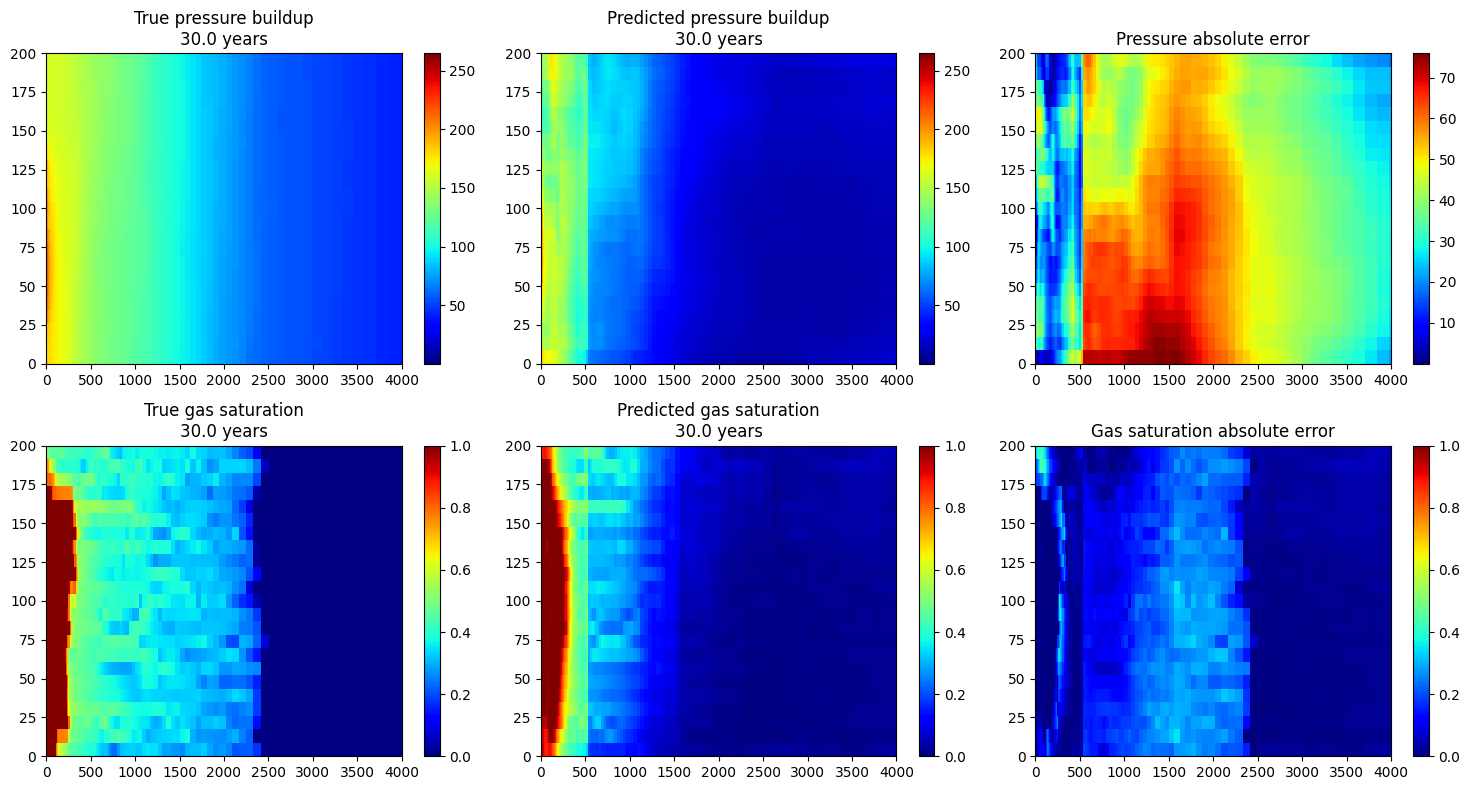

In [47]:
plot_validation_sample_physical_grid(
    model=model,
    val_dataset=val_dataset,
    val_sample_index=0, # change this to other file
    time_idx=23, # 0 = 1 day, 23 = 30 years
    device=device,
    stats=stats
)

Validation sample index: 0
Raw validation file: /content/drive/MyDrive/train_data_set/data_1419.npz
Actual nz: 23
Time: 30.0 years


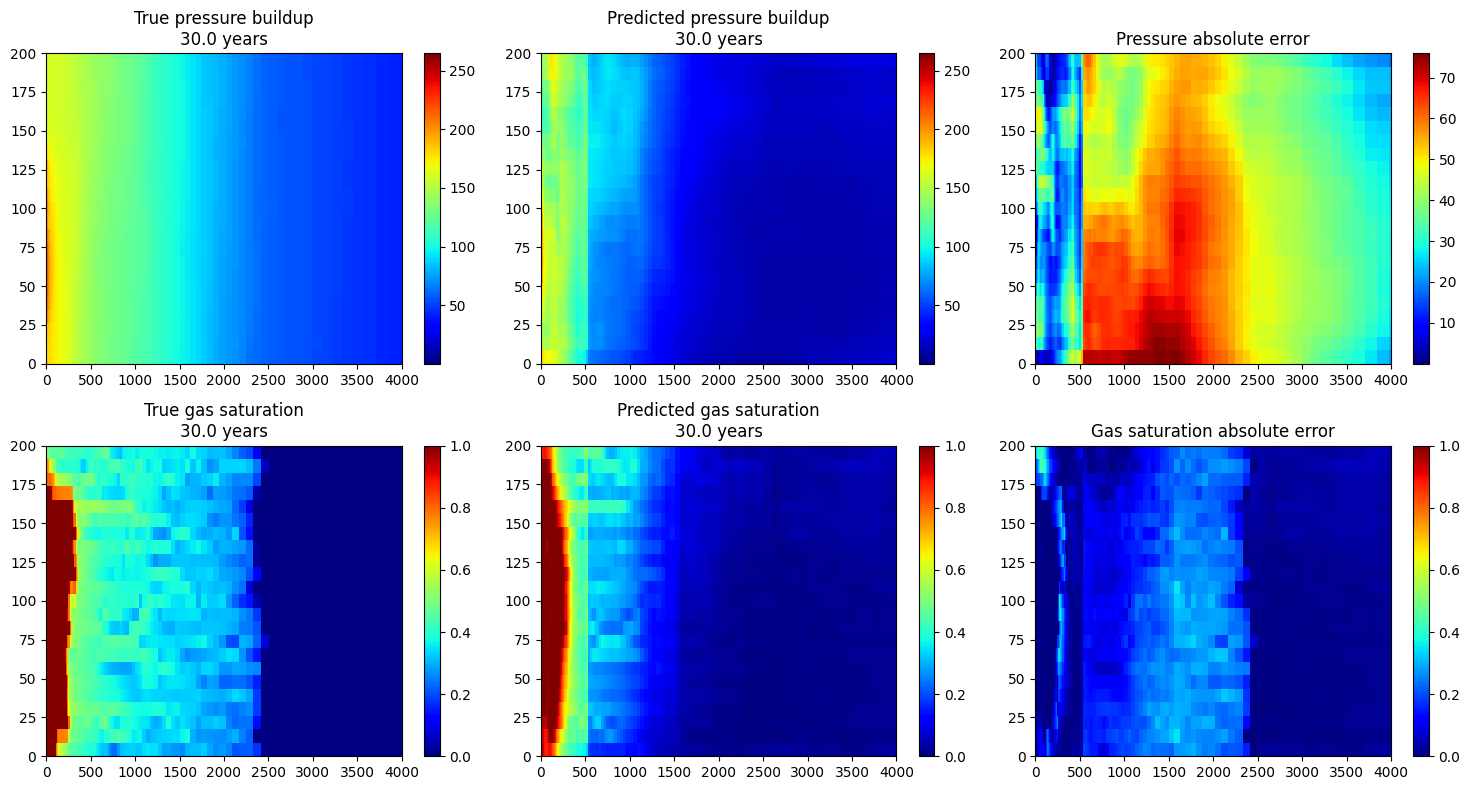

Validation sample index: 1
Raw validation file: /content/drive/MyDrive/train_data_set/data_0430.npz
Actual nz: 16
Time: 30.0 years


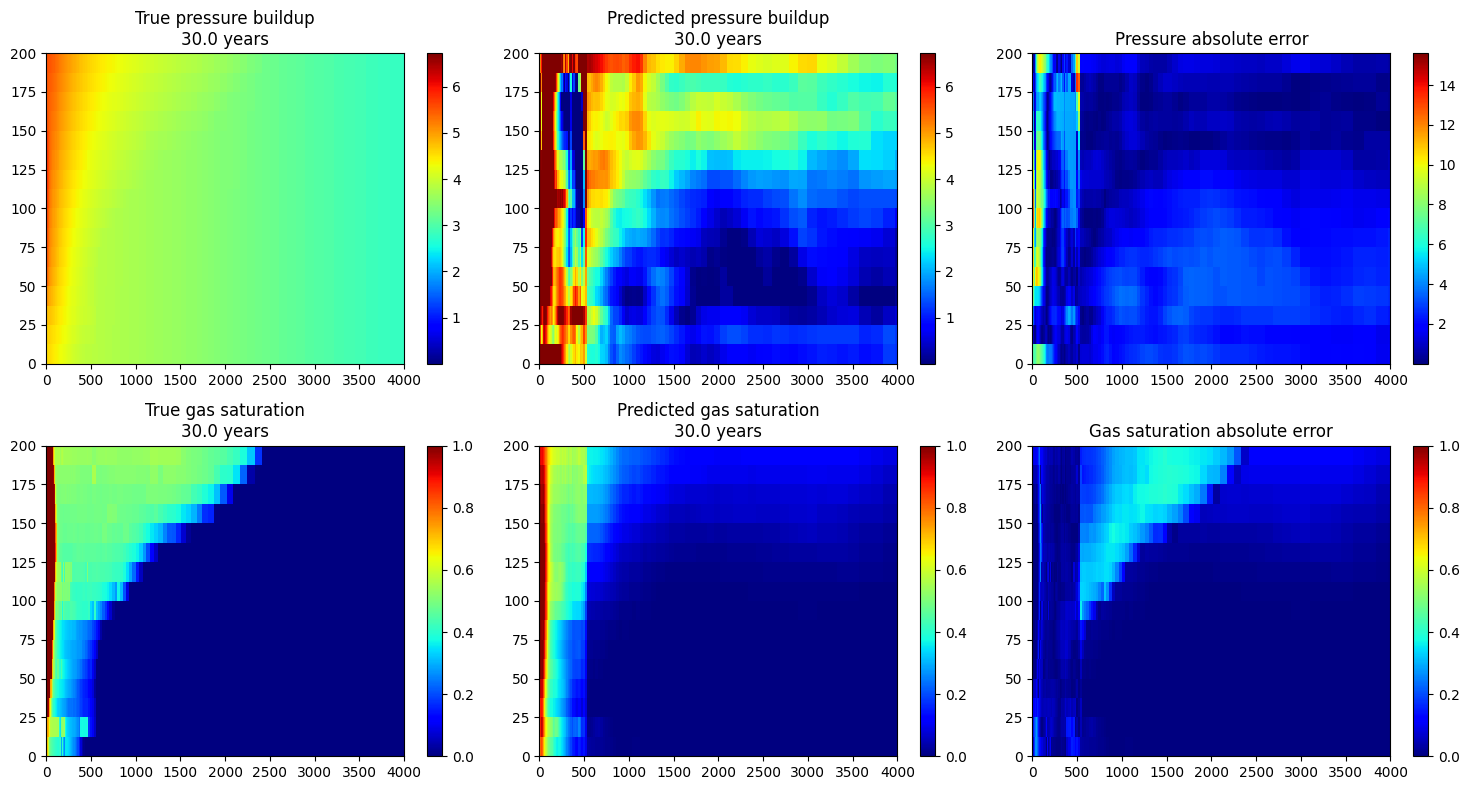

Validation sample index: 2
Raw validation file: /content/drive/MyDrive/train_data_set/data_0979.npz
Actual nz: 40
Time: 30.0 years


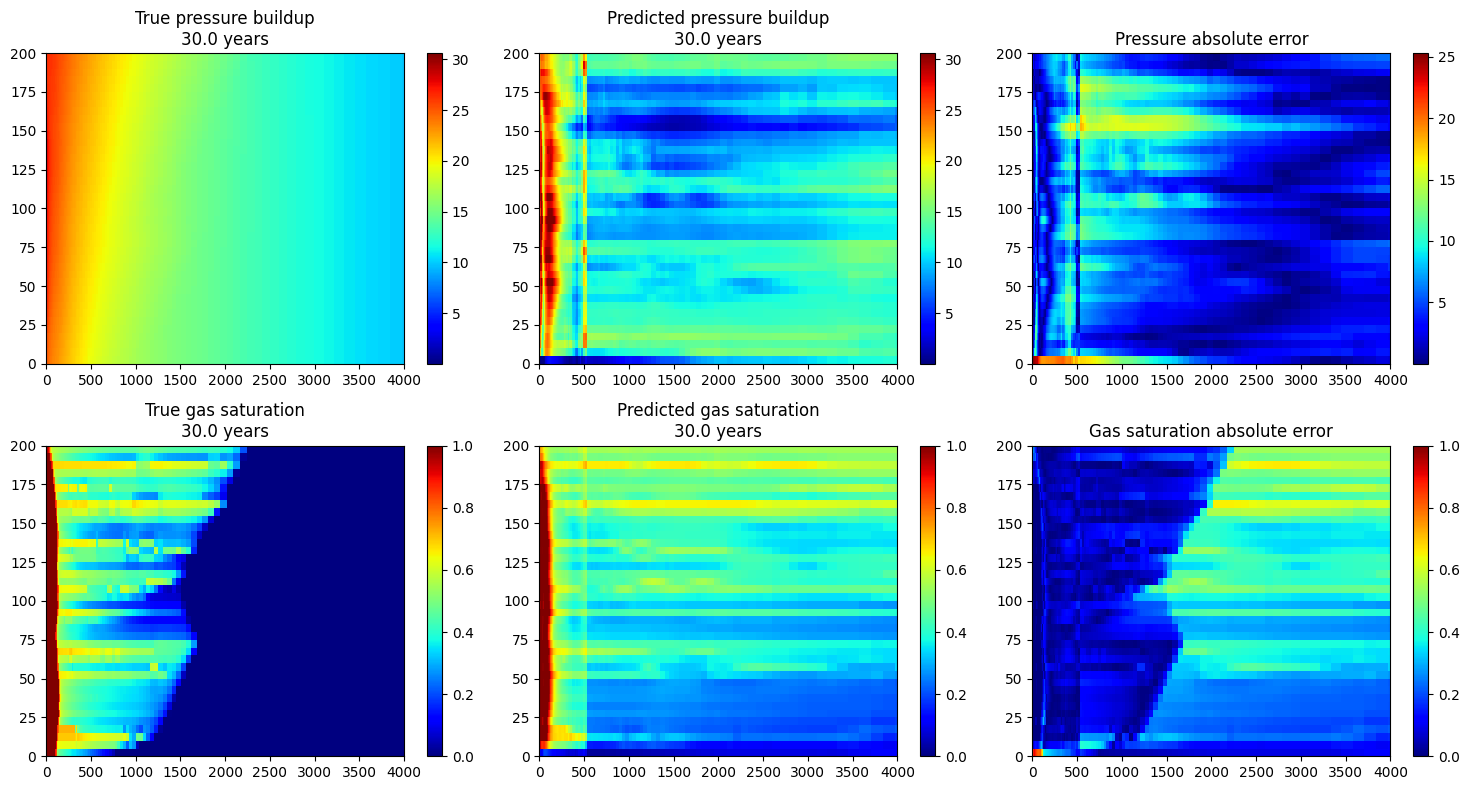

Validation sample index: 3
Raw validation file: /content/drive/MyDrive/train_data_set/data_2857.npz
Actual nz: 50
Time: 30.0 years


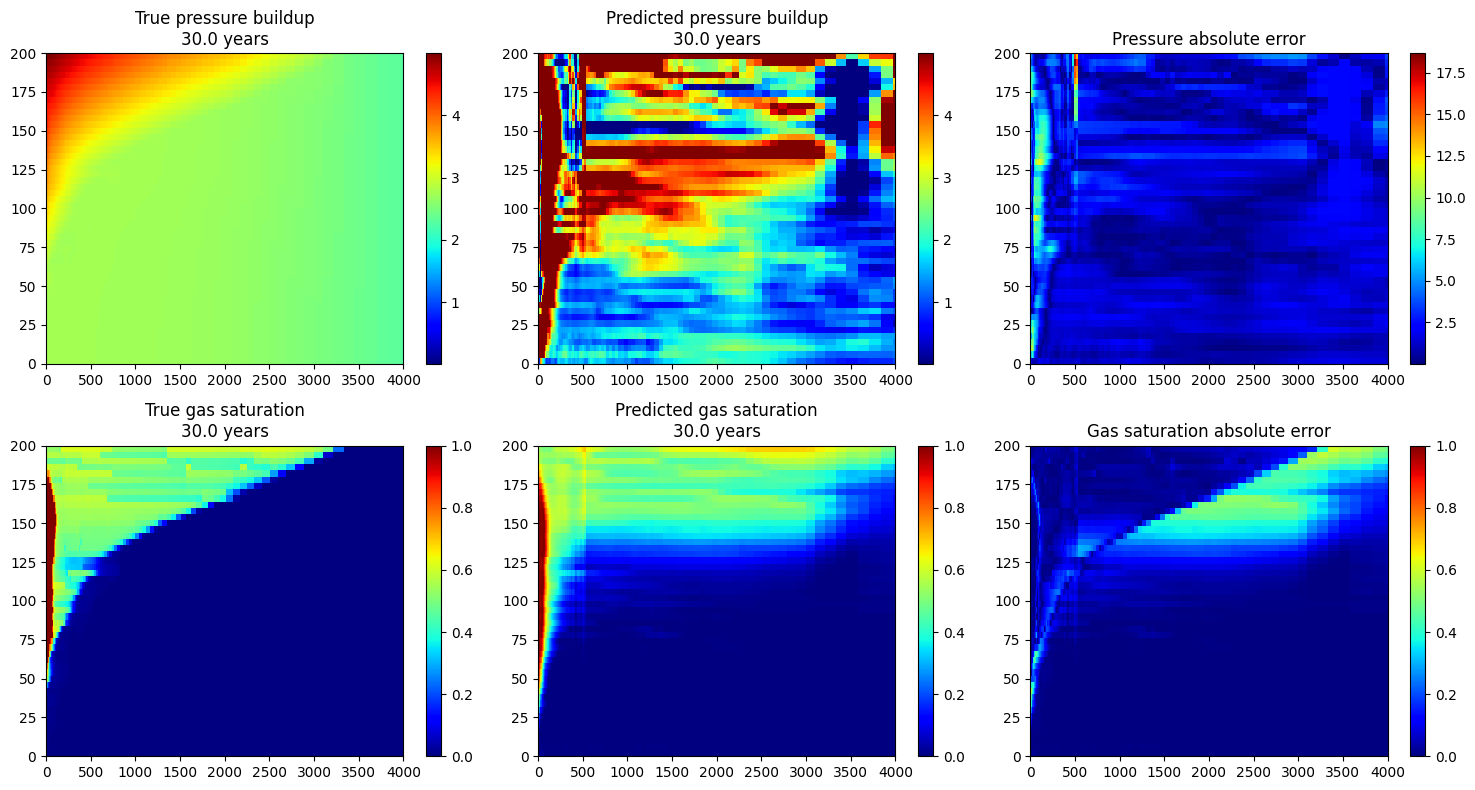

Validation sample index: 4
Raw validation file: /content/drive/MyDrive/train_data_set/data_3356.npz
Actual nz: 33
Time: 30.0 years


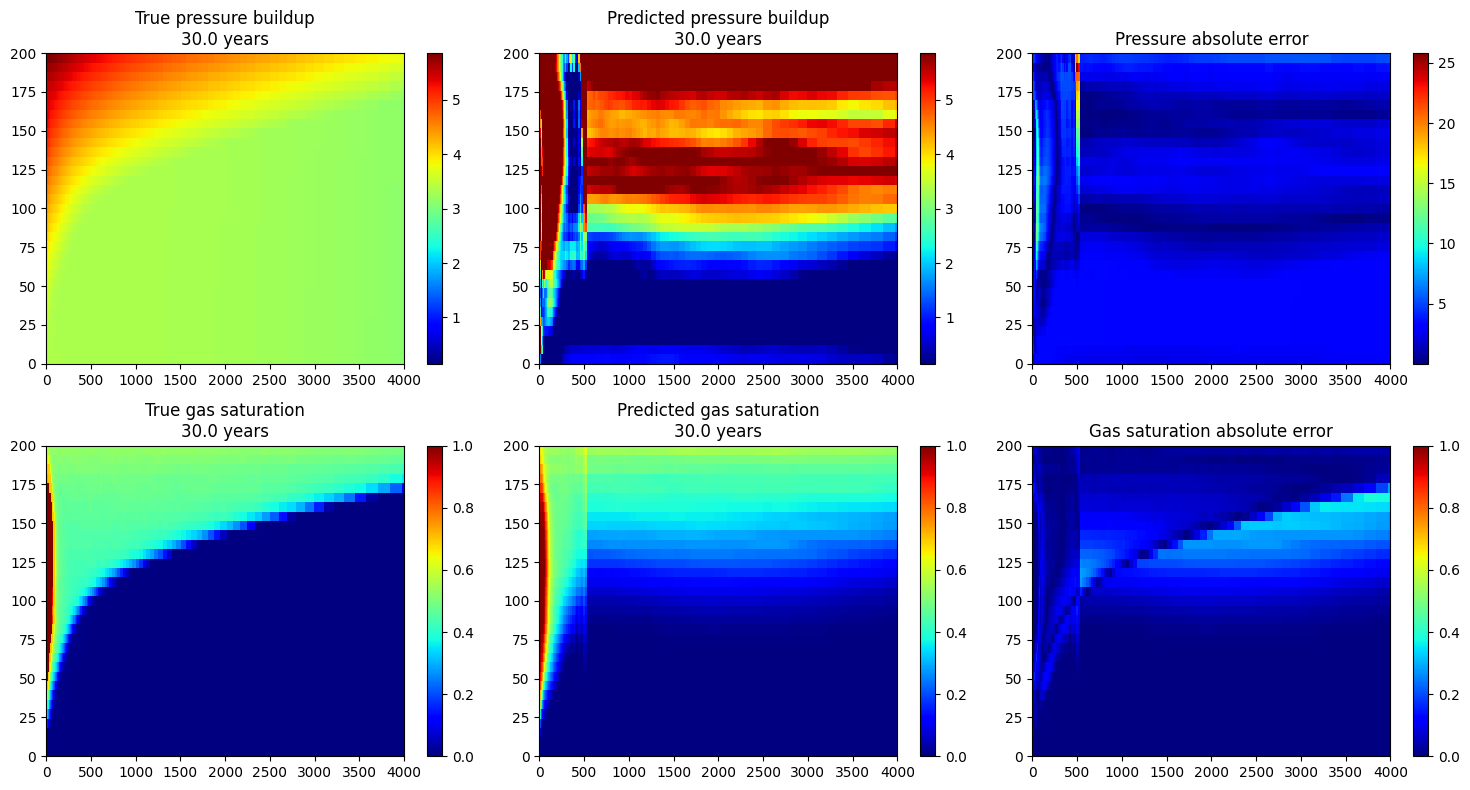

In [37]:
for i in range(5):
    plot_validation_sample_physical_grid(
        model=model,
        val_dataset=val_dataset,
        val_sample_index=i,
        time_idx=23,
        device=device,
        stats=stats
    )